# Assignment: Hypothesis Testing with Z-Test and t-Test
### Left-tailed, right-tailed and two-tailed tests on a student dataset

**Total marks:** 100  **Submit:** one `.ipynb` file

**What you will do**

You are given a small dataset of **40 college students**. Answer **6 questions**:

| Question | Test | Tail |
|---|---|---|
| Q1 | Z-test | Left |
| Q2 | Z-test | Right |
| Q3 | Z-test | Two |
| Q4 | t-test | Left |
| Q5 | t-test | Right |
| Q6 | t-test | Two |

Then fill in the summary table in Q7.

**Instructions**
1. Run the two starter cells first. **Do not change them.**
2. Write your code only in the cells marked `YOUR CODE HERE`.
3. Write your answers in the cells marked **Your answer**.
4. Use **α = 0.05** for every question.
5. Allowed libraries: `numpy`, `pandas`, `scipy.stats`, `matplotlib`.
6. Compute every number from the dataset. Do not type in the answers by hand.

## Quick Reference

| | Z-test | t-test |
|---|---|---|
| Use when | Population σ is **known** | Population σ is **unknown** |
| Formula | $z = \dfrac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$ | $t = \dfrac{\bar{x} - \mu_0}{s / \sqrt{n}}$, $df = n - 1$ |

| Tail | $H_1$ | p-value (Z) | p-value (t) | Critical value (Z, α = 0.05) |
|---|---|---|---|---|
| Left | $\mu < \mu_0$ | `stats.norm.cdf(z)` | `stats.t.cdf(t, dof)` | −1.645 |
| Right | $\mu > \mu_0$ | `1 - stats.norm.cdf(z)` | `1 - stats.t.cdf(t, dof)` | +1.645 |
| Two | $\mu \neq \mu_0$ | `2 * (1 - stats.norm.cdf(abs(z)))` | `2 * (1 - stats.t.cdf(abs(t), dof))` | ±1.960 |

**Decision rule:** if **p-value ≤ α**, reject $H_0$. Otherwise, fail to reject $H_0$.

For the sample standard deviation use `df['column'].std()`. pandas uses `ddof=1` by default, which is what the t-test needs.

⚠️ The dataset is stored in a variable called `df`. Store the degrees of freedom in a variable called **`dof`**, not `df`, or you will overwrite the dataset.

## Setup and Dataset

In [1]:
# ---------------- STARTER CODE – DO NOT MODIFY ----------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

alpha = 0.05
print("Libraries loaded. alpha =", alpha)

Libraries loaded. alpha = 0.05


In [2]:
# ---------------- STARTER CODE – DO NOT MODIFY ----------------
# Dataset: 40 students from three sections of a college course
df = pd.DataFrame({
    'student_id':  [f'S{i:02d}' for i in range(1, 41)],
    'section':     ['A'] * 14 + ['B'] * 13 + ['C'] * 13,
    'sleep_hours': [6.9, 5.5, 7.4, 7.6, 4.5, 5.2, 6.7, 6.3, 6.6, 5.7, 7.6, 7.5, 6.7, 7.8,
                    7.1, 5.7, 7.0, 5.5, 7.6, 6.5, 6.4, 5.9, 7.9, 6.4, 6.1, 6.2, 7.2,
                    7.0, 7.1, 7.1, 9.0, 6.2, 6.0, 5.7, 7.3, 7.8, 6.5, 5.7, 5.7, 7.3],
    'screen_time': [6.5, 6.2, 4.5, 5.8, 5.6, 5.8, 6.7, 5.8, 6.4, 5.5, 5.9, 6.3, 3.4, 5.0,
                    4.8, 4.6, 5.1, 7.5, 4.2, 6.8, 3.1, 5.0, 5.7, 6.3, 6.4, 6.6, 5.0,
                    4.8, 6.7, 5.2, 3.7, 3.9, 4.2, 6.1, 5.6, 6.4, 4.9, 5.7, 6.3, 5.0],
    'exam_score':  [71, 60, 63, 63, 55, 71, 62, 67, 71, 71, 73, 66, 62, 66,
                    50, 52, 53, 57, 70, 57, 63, 79, 63, 74, 57, 64, 57,
                    63, 75, 49, 71, 69, 61, 52, 67, 61, 69, 67, 83, 64],
    'attendance':  [75, 82, 82, 89, 86, 83, 90, 74, 77, 75, 79, 73, 85, 80,
                    72, 75, 83, 86, 93, 98, 83, 75, 68, 83, 76, 79, 77,
                    80, 87, 82, 80, 75, 71, 78, 81, 92, 82, 87, 78, 74],
    'study_hours': [2.2, 2.4, 4.7, 2.3, 3.7, 2.3, 3.7, 3.3, 2.9, 3.0, 2.5, 3.4, 2.6, 2.0,
                    2.0, 3.1, 4.3, 3.1, 2.9, 3.2, 4.0, 3.2, 2.7, 3.9, 3.3, 4.2, 3.1,
                    2.0, 1.9, 4.3, 4.4, 2.9, 2.7, 4.2, 2.1, 2.3, 3.5, 2.7, 3.0, 2.9],
    'commute_min': [34, 42, 33, 37, 18, 32, 26, 23, 26, 30, 38, 23, 32, 29,
                    30, 39, 36, 41, 31, 27, 30, 34, 33, 24, 33, 34, 50,
                    45, 26, 30, 22, 28, 34, 40, 27, 27, 17, 31, 25, 28],
})

print("Shape:", df.shape)
print(df['section'].value_counts().sort_index().to_string())
df.head(10)

Shape: (40, 8)
section
A    14
B    13
C    13


,student_id,section,sleep_hours,screen_time,exam_score,attendance,study_hours,commute_min
0,S01,A,6.9,6.5,71,75,2.2,34
1,S02,A,5.5,6.2,60,82,2.4,42
2,S03,A,7.4,4.5,63,82,4.7,33
3,S04,A,7.6,5.8,63,89,2.3,37
4,S05,A,4.5,5.6,55,86,3.7,18
5,S06,A,5.2,5.8,71,83,2.3,32
6,S07,A,6.7,6.7,62,90,3.7,26
7,S08,A,6.3,5.8,67,74,3.3,23
8,S09,A,6.6,6.4,71,77,2.9,26
9,S10,A,5.7,5.5,71,75,3.0,30


**Data dictionary**

| Column | Meaning |
|---|---|
| `student_id` | Student ID |
| `section` | Class section: A (14 students), B (13), C (13) |
| `sleep_hours` | Average sleep per night (hours) |
| `screen_time` | Average daily screen time (hours) |
| `exam_score` | Final exam score (out of 100) |
| `attendance` | Attendance (%) |
| `study_hours` | Average self-study per day (hours) |
| `commute_min` | One-way commute time (minutes) |

Explore the data before you start (optional):

In [3]:
# ===================== OPTIONAL – EXPLORE THE DATA =====================
# OPTIONAL: explore the dataset, e.g. df.describe() or df.groupby('section').mean(numeric_only=True)

---
# Part A – Z-Tests (σ known, use all 40 students)

## Q1. Z-Test – Left-Tailed

A health report says college students sleep **7 hours** per night on average, with a known population standard deviation of **σ = 1.2 hours**.
Using `sleep_hours` for **all 40 students**, test at α = 0.05 whether students sleep **less than 7 hours** on average.

**Steps:** (a) write $H_0$, $H_1$ and the tail, (b) find $n$ and $\bar{x}$, (c) compute $z$, (d) find the critical value and the p-value, (e) make a decision and write a conclusion.

*(15 marks)*

In [4]:
def plot_test(stat, critical, tail, dist='z', dof=None, title=''):
    x = np.linspace(-4, 4, 1000)

    if dist == 'z':
        y = stats.norm.pdf(x)
        label = 'Standard Normal Distribution'
    else:
        y = stats.t.pdf(x, dof)
        label = f't-Distribution (df = {dof})'

    plt.figure(figsize=(10, 5))
    plt.plot(x, y, label=label)

    # Rejection region
    if tail == 'left':
        region = x <= critical
        plt.fill_between(x, y, where=region,
                         alpha=0.3, label='Rejection Region')
        plt.axvline(critical, linestyle=':', linewidth=2,
                    label=f'Critical = {critical:.3f}')

    elif tail == 'right':
        region = x >= critical
        plt.fill_between(x, y, where=region,
                         alpha=0.3, label='Rejection Region')
        plt.axvline(critical, linestyle=':', linewidth=2,
                    label=f'Critical = {critical:.3f}')

    else:
        region = np.abs(x) >= critical
        plt.fill_between(x, y, where=region,
                         alpha=0.3, label='Rejection Regions')
        plt.axvline(-critical, linestyle=':', linewidth=2,
                    label=f'Critical = ±{critical:.3f}')
        plt.axvline(critical, linestyle=':', linewidth=2)

    # Test statistic
    plt.axvline(stat, linestyle='--', linewidth=2,
                label=f'Test Statistic = {stat:.3f}')

    plt.axvline(0, linewidth=1)

    plt.title(title)
    plt.xlabel('z' if dist == 'z' else 't')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

n = 40
Mean = 6.647499999999999
Z statistic = -1.8578381253489278
Critical value = -1.6448536269514729
p-value = 0.03159600261338476
Decision: Reject H0
Conclusion: Average sleep time is less than 7 hours.


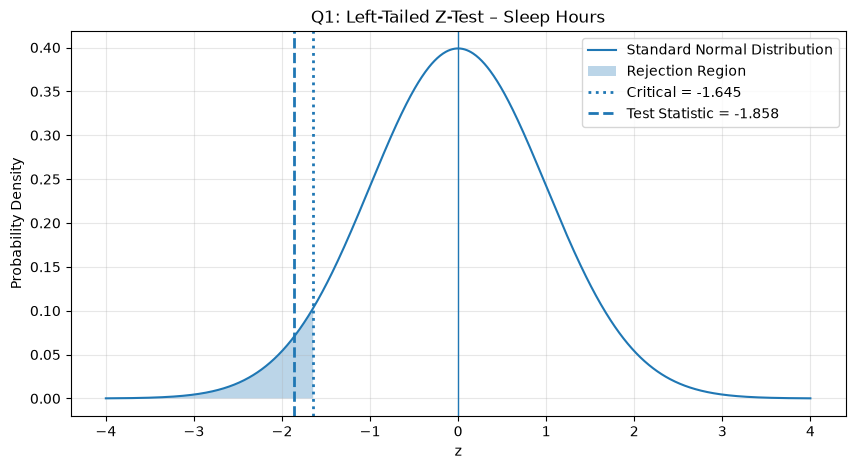

In [5]:
# ===================== Q1 – YOUR CODE HERE =====================
# Z-test, left-tailed: column 'sleep_hours', mu_0 = 7, sigma = 1.2, all 40 students

# Q1 – Z-test, left-tailed

data = df['sleep_hours']
mu_0 = 7
sigma = 1.2

n = len(data)
x_bar = data.mean()

z = (x_bar - mu_0) / (sigma / np.sqrt(n))

critical_value = stats.norm.ppf(alpha)
p_value = stats.norm.cdf(z)

print("n =", n)
print("Mean =", x_bar)
print("Z statistic =", z)
print("Critical value =", critical_value)
print("p-value =", p_value)

if p_value <= alpha:
    print("Decision: Reject H0")
    print("Conclusion: Average sleep time is less than 7 hours.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: There is not enough evidence that average sleep time is less than 7 hours.")

plot_test(
    z,
    critical_value,
    'left',
    dist='z',
    title='Q1: Left-Tailed Z-Test – Sleep Hours'
)


**Your answer – Q1**

- **$H_0$:μ=7**
- **$H_1$:μ<7**
- **Tail (left / right / two):Left-Tailed**
- **Test statistic:  z=-1.8578**
- **Critical value: -1.645**
- **p-value: 0.031596**
- **Decision (Reject $H_0$ / Fail to reject $H_0$): Reject H0**
- **Conclusion in words: There is sufficient evidence at the 5% significance level to conclude that the average sleep time of these students is less than 7 hours per night.**

## Q2. Z-Test – Right-Tailed

A national survey says young adults spend **5 hours** a day on screens, with a known population standard deviation of **σ = 1.5 hours**.
Using `screen_time` for **all 40 students**, test at α = 0.05 whether these students' screen time is **more than 5 hours** a day.

**Steps:** (a) write $H_0$, $H_1$ and the tail, (b) find $n$ and $\bar{x}$, (c) compute $z$, (d) find the critical value and the p-value, (e) make a decision and write a conclusion.

*(15 marks)*

n = 40
Mean = 5.475
Z statistic = 2.002775851439972
Critical value = 1.644853626951472
p-value = 0.02260067648826114
Decision: Reject H0
Conclusion: Average screen time is more than 5 hours.


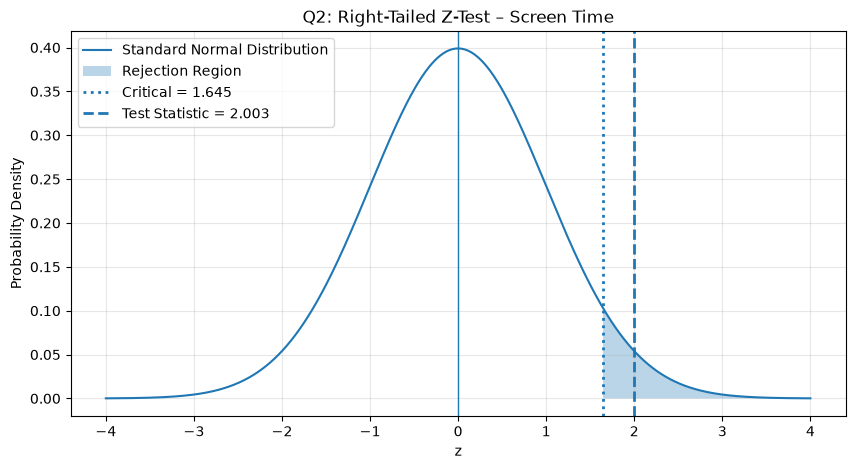

In [6]:
# ===================== Q2 – YOUR CODE HERE =====================
# Z-test, right-tailed: column 'screen_time', mu_0 = 5, sigma = 1.5, all 40 students


data = df['screen_time']
mu_0 = 5
sigma = 1.5

n = len(data)
x_bar = data.mean()

z = (x_bar - mu_0) / (sigma / np.sqrt(n))

critical_value = stats.norm.ppf(1 - alpha)
p_value = 1 - stats.norm.cdf(z)

print("n =", n)
print("Mean =", x_bar)
print("Z statistic =", z)
print("Critical value =", critical_value)
print("p-value =", p_value)

if p_value <= alpha:
    print("Decision: Reject H0")
    print("Conclusion: Average screen time is more than 5 hours.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: There is not enough evidence that average screen time is more than 5 hours.")

plot_test(
    z,
    critical_value,
    'right',
    dist='z',
    title='Q2: Right-Tailed Z-Test – Screen Time'
)

**Your answer – Q2**
 
- **$H_0$:μ=5**
- **$H_1$:μ>5**
- **Tail (left / right / two): Right- Tailed**
- **Test statistic: z = 2.0028**
- **Critical value: 1.645**
- **p-value: 0.022601**
- **Decision (Reject $H_0$ / Fail to reject $H_0$):Reject H_0**
- **Conclusion in words: There is sufficient evidence at the 5% significance level to conclude that the average screen time of these students is more than 7 hours per day.**

## Q3. Z-Test – Two-Tailed

Over many years, the course's final exam has had a mean of **65** with a known standard deviation of **σ = 10**.
Using `exam_score` for **all 40 students**, test at α = 0.05 whether this year's mean score is **different from 65**.

**Steps:** (a) write $H_0$, $H_1$ and the tail, (b) find $n$ and $\bar{x}$, (c) compute $z$, (d) find the critical value and the p-value, (e) make a decision and write a conclusion.

*(15 marks)*

n = 40
Mean = 64.2
Z statistic = -0.5059644256269389
Critical values = -1.959963984540054 and 1.959963984540054
p-value = 0.6128816234132377
Decision: Fail to reject H0
Conclusion: There is not enough evidence that mean exam score is different from 65.


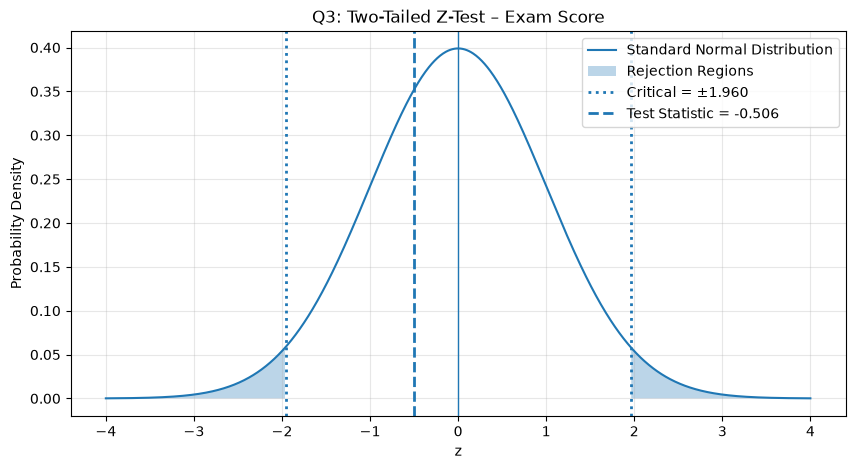

In [7]:
# ===================== Q3 – YOUR CODE HERE =====================
# Z-test, two-tailed: column 'exam_score', mu_0 = 65, sigma = 10, all 40 students

data = df['exam_score']
mu_0 = 65
sigma = 10

n = len(data)
x_bar = data.mean()

z = (x_bar - mu_0) / (sigma / np.sqrt(n))

critical_value = stats.norm.ppf(1 - alpha / 2)
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print("n =", n)
print("Mean =", x_bar)
print("Z statistic =", z)
print("Critical values =", -critical_value, "and", critical_value)
print("p-value =", p_value)

if p_value <= alpha:
    print("Decision: Reject H0")
    print("Conclusion: Mean exam score is significantly different from 65.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: There is not enough evidence that mean exam score is different from 65.")

plot_test(
    z,
    critical_value,
    'two',
    dist='z',
    title='Q3: Two-Tailed Z-Test – Exam Score'
)


**Your answer – Q3**
 
- **$H_0$:μ=65**
- **$H_1$:μ≠65**
- **Tail (left / right / two): Two- Tailed**
- **Test statistic: z = -.05060**
- **Critical value: -1.960,+1.960**
- **p-value: 0.612882**
- **Decision (Reject $H_0$ / Fail to reject $H_0$):Fail to Reject H_0**
- **Conclusion in words: There is sufficient evidence at the 5% significance level to conclude that this year's average exam score is different from 65**

---
# Part B – t-Tests (σ unknown, use one section only)

Select one section like this: `df[df['section'] == 'B']['attendance']`

## Q4. t-Test – Left-Tailed

The class teacher of **Section B** believes her students' attendance is **below 83 %**. The population standard deviation is **not known**.
Using `attendance` for **Section B only**, test at α = 0.05 whether the mean attendance is **less than 83 %**.

**Steps:** (a) write $H_0$, $H_1$ and the tail, (b) select the rows for the section, then find $n$, $\bar{x}$, $s$ and $df$, (c) compute $t$, (d) find the critical value and the p-value, (e) make a decision and write a conclusion, (f) check your answer with `stats.ttest_1samp(data, popmean, alternative=...)`.

*(15 marks)*

n = 13
Mean = 80.61538461538461
Sample standard deviation = 8.342046726657887
Degrees of freedom = 12
t statistic = -1.0306646945546007
Critical value = -1.7822875556493198
p-value = 0.16151225409771375
Decision: Fail to reject H0
Conclusion: There is not enough evidence that Section B mean attendance is less than 83%.
TtestResult(statistic=np.float64(-1.0306646945546007), pvalue=np.float64(0.16151225409771375), df=np.int64(12))


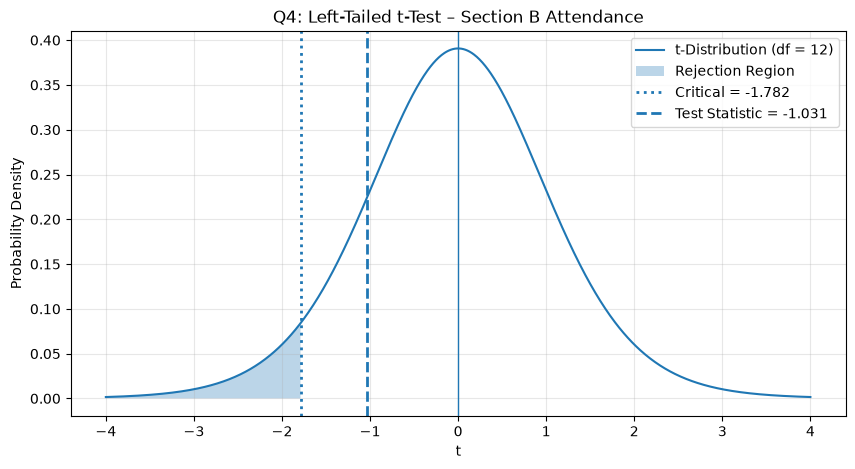

In [8]:
# ===================== Q4 – YOUR CODE HERE =====================
# t-test, left-tailed: column 'attendance', Section B only, mu_0 = 83, sigma unknown

data = df[df['section'] == 'B']['attendance']
mu_0 = 83

n = len(data)
x_bar = data.mean()
s = data.std()
dof = n - 1

t = (x_bar - mu_0) / (s / np.sqrt(n))

critical_value = stats.t.ppf(alpha, dof)
p_value = stats.t.cdf(t, dof)

print("n =", n)
print("Mean =", x_bar)
print("Sample standard deviation =", s)
print("Degrees of freedom =", dof)
print("t statistic =", t)
print("Critical value =", critical_value)
print("p-value =", p_value)

if p_value <= alpha:
    print("Decision: Reject H0")
    print("Conclusion: Section B mean attendance is less than 83%.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: There is not enough evidence that Section B mean attendance is less than 83%.")

print(stats.ttest_1samp(data, mu_0, alternative='less'))


plot_test(
    t,
    critical_value,
    'left',
    dist='t',
    dof=dof,
    title='Q4: Left-Tailed t-Test – Section B Attendance'
)


**Your answer – Q4**
 
- **$H_0$:μ=83**
- **$H_1$:μ<83**
- **Tail (left / right / two): Left- Tailed**
- **Test statistic: t = -1.0307**
- **Critical value: -1.7823**
- **p-value: 0.161512**
- **Decision (Reject $H_0$ / Fail to reject $H_0$):Reject H_0**
- **Conclusion in words: There is sufficient evidence at the 5% significance level to conclude that Section B's mean attendence is less than 83%.**

## Q5. t-Test – Right-Tailed

The college recommends at least **2.5 hours** of self-study per day. The teacher of **Section A** claims her students study **more than 2.5 hours** a day on average. σ is **not known**.
Using `study_hours` for **Section A only**, test the claim at α = 0.05.

**Steps:** (a) write $H_0$, $H_1$ and the tail, (b) select the rows for the section, then find $n$, $\bar{x}$, $s$ and $df$, (c) compute $t$, (d) find the critical value and the p-value, (e) make a decision and write a conclusion, (f) check your answer with `stats.ttest_1samp(data, popmean, alternative=...)`.

*(15 marks)*

n = 14
Mean = 2.9285714285714284
Sample standard deviation = 0.7569458586761889
Degrees of freedom = 13
t statistic = 2.1184704732766493
Critical value = 1.7709333959868727
p-value = 0.02698523465440561
Decision: Reject H0
Conclusion: Section A students study more than 2.5 hours per day.
TtestResult(statistic=np.float64(2.1184704732766493), pvalue=np.float64(0.02698523465440562), df=np.int64(13))


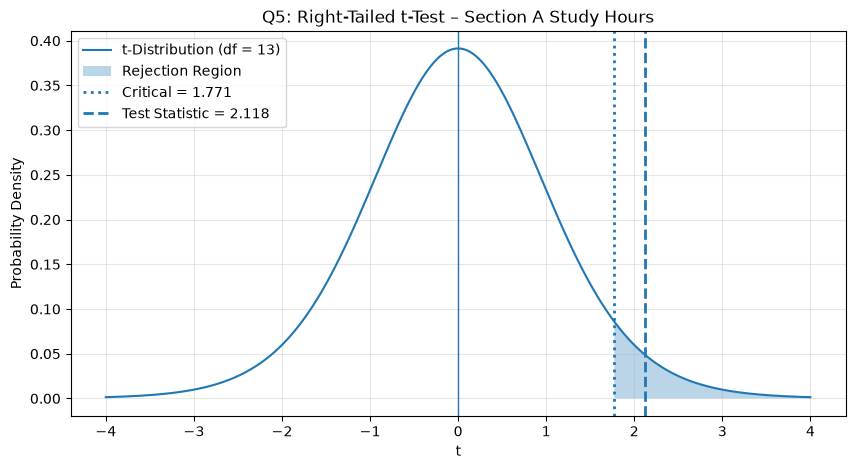

In [9]:
# ===================== Q5 – YOUR CODE HERE =====================
# t-test, right-tailed: column 'study_hours', Section A only, mu_0 = 2.5, sigma unknown


data = df[df['section'] == 'A']['study_hours']
mu_0 = 2.5

n = len(data)
x_bar = data.mean()
s = data.std()
dof = n - 1

t = (x_bar - mu_0) / (s / np.sqrt(n))

critical_value = stats.t.ppf(1 - alpha, dof)
p_value = 1 - stats.t.cdf(t, dof)

print("n =", n)
print("Mean =", x_bar)
print("Sample standard deviation =", s)
print("Degrees of freedom =", dof)
print("t statistic =", t)
print("Critical value =", critical_value)
print("p-value =", p_value)

if p_value <= alpha:
    print("Decision: Reject H0")
    print("Conclusion: Section A students study more than 2.5 hours per day.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: There is not enough evidence that Section A students study more than 2.5 hours.")

print(stats.ttest_1samp(data, mu_0, alternative='greater'))


plot_test(
    t,
    critical_value,
    'right',
    dist='t',
    dof=dof,
    title='Q5: Right-Tailed t-Test – Section A Study Hours'
)


**Your answer – Q5**
 
- **$H_0$:μ=2.5**
- **$H_1$:μ>2.5**
- **Tail (left / right / two): Right- Tailed**
- **Test statistic: t = 2.1185**
- **Critical value: 1.7709**
- **p-value: 0.026985**
- **Decision (Reject $H_0$ / Fail to reject $H_0$):Reject H_0**
- **Conclusion in words: There is sufficient evidence at the 5% significance level to conclude that Section A students study more than 2.5 hours per day on average.**

## Q6. t-Test – Two-Tailed

The transport office plans the college bus timetable assuming an average one-way commute of **35 minutes**. σ is **not known**.
Using `commute_min` for **Section C only**, test at α = 0.05 whether the mean commute time is **different from 35 minutes**.

**Steps:** (a) write $H_0$, $H_1$ and the tail, (b) select the rows for the section, then find $n$, $\bar{x}$, $s$ and $df$, (c) compute $t$, (d) find the critical value and the p-value, (e) make a decision and write a conclusion, (f) check your answer with `stats.ttest_1samp(data, popmean, alternative=...)`.

*(15 marks)*

n = 13
Mean = 29.23076923076923
Sample standard deviation = 7.270417756839999
Degrees of freedom = 12
t statistic = -2.86108144733173
Critical values = -2.1788128296672284 and 2.1788128296672284
p-value = 0.014325046371812533
Decision: Reject H0
Conclusion: Section C mean commute time is different from 35 minutes.
TtestResult(statistic=np.float64(-2.86108144733173), pvalue=np.float64(0.014325046371812642), df=np.int64(12))


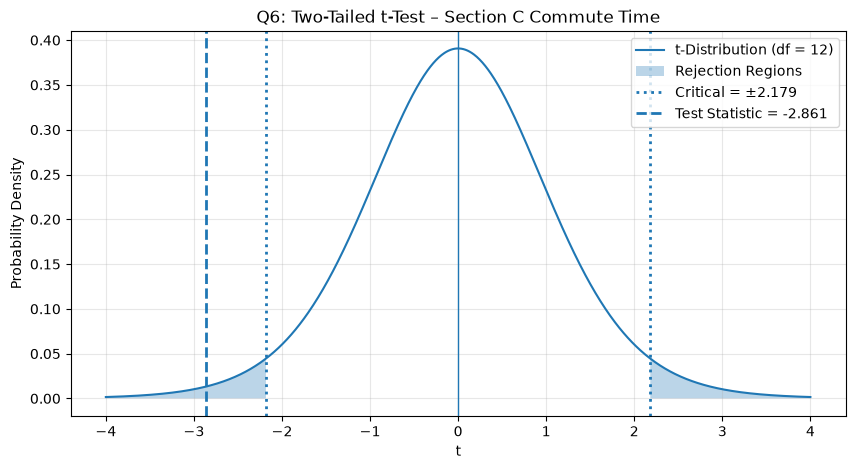

In [10]:
# ===================== Q6 – YOUR CODE HERE =====================
# t-test, two-tailed: column 'commute_min', Section C only, mu_0 = 35, sigma unknown


data = df[df['section'] == 'C']['commute_min']
mu_0 = 35

n = len(data)
x_bar = data.mean()
s = data.std()
dof = n - 1

t = (x_bar - mu_0) / (s / np.sqrt(n))

critical_value = stats.t.ppf(1 - alpha / 2, dof)
p_value = 2 * (1 - stats.t.cdf(abs(t), dof))

print("n =", n)
print("Mean =", x_bar)
print("Sample standard deviation =", s)
print("Degrees of freedom =", dof)
print("t statistic =", t)
print("Critical values =", -critical_value, "and", critical_value)
print("p-value =", p_value)

if p_value <= alpha:
    print("Decision: Reject H0")
    print("Conclusion: Section C mean commute time is different from 35 minutes.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: There is not enough evidence that Section C mean commute time is different from 35 minutes.")


print(stats.ttest_1samp(data, mu_0, alternative='two-sided'))



plot_test(
    t,
    critical_value,
    'two',
    dist='t',
    dof=dof,
    title='Q6: Two-Tailed t-Test – Section C Commute Time'
)

**Your answer – Q6**

- **$H_0$:**
- **$H_1$:**
- **Tail (left / right / two):**
- **Test statistic:**
- **Critical value:**
- **p-value:**
- **Decision (Reject $H_0$ / Fail to reject $H_0$):**
- **Conclusion in words:**


**Your answer – Q6**
 
- **$H_0$:μ=35**
- **$H_1$:μ≠35**
- **Tail (left / right / two): Two-Tailed**
- **Test statistic: t = -2.8611**
- **Critical value: -2.1788 , +2.1788**
- **p-value: 0.014325**
- **Decision (Reject $H_0$ / Fail to reject $H_0$):Reject H_0**
- **Conclusion in words: There is sufficient evidence at the 5% significance level to conclude that Section C's mean onw-way commute time is different from 35 minutes.**

---
## Q7. Summary Table *(10 marks)*

Fill in the table with your results, then answer the two short questions below it.

**Your answer – Q7**

| Q      | Test   | Tail  |   Statistic | Critical value |      p-value | Decision                   |
| ------ | ------ | ----- | ----------: | -------------: | -----------: | -------------------------- |
| **Q1** | Z-test | Left  | **-1.8578** |     **-1.645** | **0.031596** | **Reject \(H_0\)**         |
| **Q2** | Z-test | Right |  **2.0028** |      **1.645** | **0.022601** | **Reject \(H_0\)**         |
| **Q3** | Z-test | Two   | **-0.5060** |     **±1.960** | **0.612882** | **Fail to reject \(H_0\)** |
| **Q4** | t-test | Left  | **-1.0307** |    **-1.7823** | **0.161512** | **Fail to reject \(H_0\)** |
| **Q5** | t-test | Right |  **2.1185** |     **1.7709** | **0.026985** | **Reject \(H_0\)**         |
| **Q6** | t-test | Two   | **-2.8611** |    **±2.1788** | **0.014325** | **Reject \(H_0\)**         |

**(a)** Why did Q1–Q3 use a Z-test, while Q4–Q6 used a t-test?

Q1–Q3 use a Z-test because the population standard deviation \(\sigma\) is given as known.
Q4–Q6 use a t-test because the population standard deviation is unknown, so the sample standard deviation \(s\) is used instead. The t-test also uses:
$$ df=n-1 $$


**(b)** In Q3 and Q4 you failed to reject $H_0$. Does this prove that $H_0$ is true? Explain in one or two sentences.

**No**. Failing to reject \(H_0\) does not prove that \(H_0\) is true. It only means that the sample provides insufficient statistical evidence against \(H_0\) at the chosen significance level of 0.05.


---
## Submission Guidelines

1. Complete every `YOUR CODE HERE` cell and every **Your answer** cell.
2. Before submitting, click **Kernel → Restart & Run All** (in Colab: **Runtime → Restart session and run all**). Make sure there are no errors and all outputs are visible.
3. Do not delete or change the starter cells.
4. Save the file as `RollNumber_Name_ZtTest.ipynb` (for example `23CS1042_Ananya_ZtTest.ipynb`).
5. Submit **only the `.ipynb` file** on the LMS before the deadline. PDF, HTML or `.py` files are not accepted.
6. This is an individual assignment. Do not copy code or answers from classmates.

**Marking:** Q1–Q6 are worth 15 marks each: hypotheses and tail (3), correct calculations (6), decision (3) and conclusion in words (3). Q7 is worth 10 marks. Total = 100.